# Creation of Different Polirized and Time-Resolved Systems in MaRs


This notebook demonstrates how to use the MaRs library to compute polirized and time-resolved spectra of the most common EPR systems. We strongly recommend that you first review Example 1, then Example 5, and then begin working with this notebook.

This notebook demonstrates:


1) The creation of different spin-systems
2) The setting time-resolved spectra of different systems


\
\
\
\
\
\
For any questions, please contact Arkady Samsonenko via: \
Telegram: @Arkady_Samsonenko \
Email: a.samsonenko.tomo.nsc.ru
\
\
\
The last notebook update: 2026.07.30

In [1]:
# Import necessary libraries
import sys
import os
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

# Import Mars library components
import mars
from mars import spin_model, spectra_manager, mesher, constants
from mars import utils
from mars import population

# # Let's import some useful functions for plotting simulation results over time.
from mars import visualization

In [2]:
dtype = torch.float64
device = torch.device("cpu")

# 1. Spin-Polarized Spectra

In this chapter we simulate stationary EPR spectra of common spin systems
exhibiting non-Boltzmann spin polarization. Each subsection introduces a different physical mechanism
that generates the initial population imbalance among spin sublevels, and we compute the
resulting 1D powder-averaged spectrum.

The key idea is that the *initial populations* of the spin sublevels are set by the
photochemical generation mechanism (ISC, radical-pair recombination, etc.) rather than by
thermal equilibrium. We set these populations through the `population.Context` object,
choosing the appropriate basis (`"xyz"`, `"zfs"`, or `"multiplet"`) for the problem at hand.

In [3]:
def plot_polirized_spectra(context: population.BaseContext,
                           sample: spin_model.MultiOrientedSample,
                           plot_name: str,
                           field_range = (0.3, 0.4)) ->\
                           tuple[torch.Tensor, torch.Tensor]:
    spectra_creator = spectra_manager.StationarySpectra(
    freq=9.8e9,    # Frequency in Hz
    sample=sample,
    harmonic=0,      # absorbtion
    context=context, 
    temperature=300.0,  # Let's set the room temperature
    device=device,
    dtype=dtype
    )
    fields = torch.linspace(field_range[0], field_range[1], 1000, dtype=dtype, device=device)  # Field in Tesla
    spectrum = spectra_creator(sample, fields)
    
    plt.plot(fields, spectrum)
    plt.xlabel("Field (T)")
    plt.ylabel("Intensity (arb. units)")
    plt.title(plot_name)

### 1.1. Inter-System Crossing (ISC) Triplets

Upon photoexcitation, a molecule may undergo spin–orbit-driven inter-system crossing from
the singlet excited state S1 to the triplet T1. Because the SOC matrix elements
differ for the three triplet sublevels |Tx⟩, |Ty⟩, |Tz⟩ (molecular frame), the ISC
rates into each sublevel are unequal, producing a *polarized* triplet population immediately
after the laser flash.

We set the initial populations in the molecular ("xyz") or ZFS basis and let the
library transform them to the laboratory frame.

In [4]:
# Just the sample creation as usual

g_tensor = spin_model.Interaction([2.02, 2.02, 2.02], dtype=dtype, device=device)  


zfs_interaction = spin_model.DEInteraction([500e6, 100e6], dtype=dtype, device=device)  # 500 and 100 MHz

base_spin_system = spin_model.SpinSystem(
    electrons=[1.0],  # S=1 triplet
    g_tensors=[g_tensor],
    electron_electron=[(0, 0, zfs_interaction)],
    device=device,
    dtype=dtype
)

triplet = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system,
    ham_strain=3e7,
    gauss=0.001,
    lorentz=0.001,
    device=device,
    dtype=dtype
)

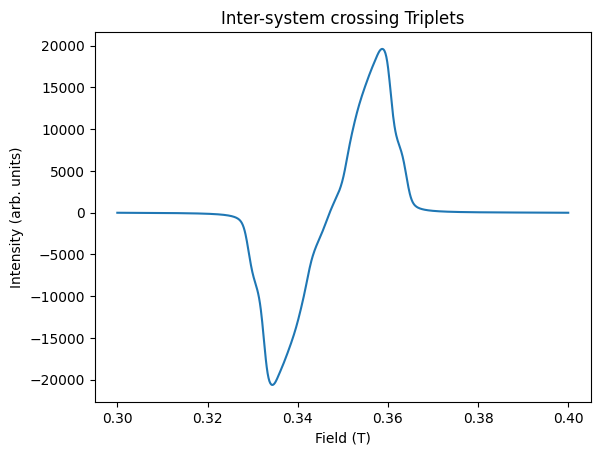

In [5]:
# Let's create context as usual

# Define initial populations (e.g., representing a specific CIDEP polarization pattern)
init_populations = [0.3, 0.5, 0.2] # Tx, Ty, Tz

context = population.Context(sample=triplet,
                             basis="xyz",
                             init_populations=init_populations, device=device, dtype=dtype)

# And plot the spectra
plot_polirized_spectra(context, triplet, "Inter-system crossing Triplets")

### 1.2. Recombination Triplets

When a spin-correlated radical pair (SCRP) is born from a singlet precursor, the S–T0
mixing driven by Δg converts some singlet character into T0.
If the radicals recombine from the singlet channel, the surviving pairs are enriched in T0.

The initial density matrix is dominated by the |T0⟩⟨T0| element in the high-field basis.

In [6]:
# Use the same sample as in the previous example

g_tensor = spin_model.Interaction([2.02, 2.02, 2.02], dtype=dtype, device=device)  

zfs_interaction = spin_model.DEInteraction([500e6, 100e6], dtype=dtype, device=device)  # 500 and 100 MHz

base_spin_system = spin_model.SpinSystem(
    electrons=[1.0], 
    g_tensors=[g_tensor],
    electron_electron=[(0, 0, zfs_interaction)],
    device=device,
    dtype=dtype
)

triplet = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system,
    ham_strain=3e7,
    gauss=0.001,
    lorentz=0.001,
    device=device,
    dtype=dtype
)

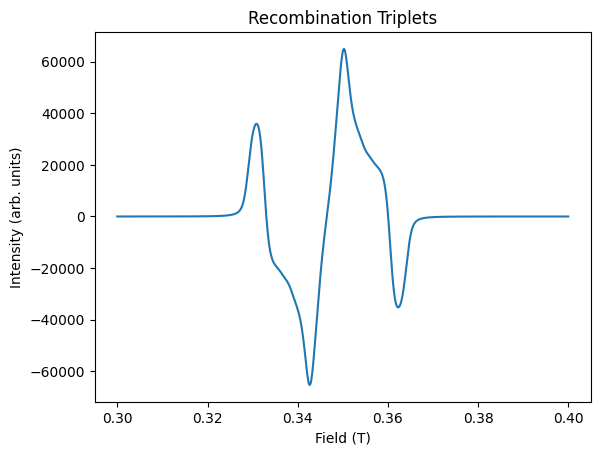

In [7]:
# Define initial populations for the spin states (e.g., T-, T0, T+)
# Here we assume complete initial population in the middle state
init_populations = [0.0, 1.0, 0.0]

# Create the population context
# basis="eigen" uses the eigenbasis of the Hamiltonian of a system. 
context = population.Context(sample=triplet,
                             basis="eigen",  # It is also possible to set here another basis (zeeman, multiplet)
                             init_populations=init_populations, device=device, dtype=dtype)

# And plot the spectra
plot_polirized_spectra(context, triplet, "Recombination Triplets")

### 1.3. Spin-Correlated Radical Pairs (SCRP) from a Singlet Precursor

A geminate radical pair created by photoinduced electron transfer from a singlet excited
state starts in the pure |S⟩ state.

Here we model a two-electron system with exchange coupling *J* and dipolar coupling *D*,
and set the initial state to |S⟩⟨S| in the multiplet (S/T) basis.

In [8]:
g_tensor_1 = spin_model.Interaction([2.02, 2.03, 2.04], dtype=dtype, device=device)  # Some anisotropy
g_tensor_2 = spin_model.Interaction([2.03, 2.025, 2.025], dtype=dtype, device=device)  # Some anisotropy

dip_interaction = spin_model.DEInteraction([100 * 1e6, 10 * 1e6], dtype=dtype, device=device)  # 100 and 10 MHz
exchange_interaction = spin_model.Interaction(400 * 1e6, dtype=dtype, device=device)  # 400 MHz

base_spin_system = spin_model.SpinSystem(
    electrons=[0.5, 0.5], 
    g_tensors=[g_tensor_1, g_tensor_2],
    electron_electron=[(0, 1, dip_interaction + exchange_interaction)],
    device=device,
    dtype=dtype
)

radical_pair = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system,
    gauss=0.001,
    lorentz=0.001,
    device=device,
    dtype=dtype,
)

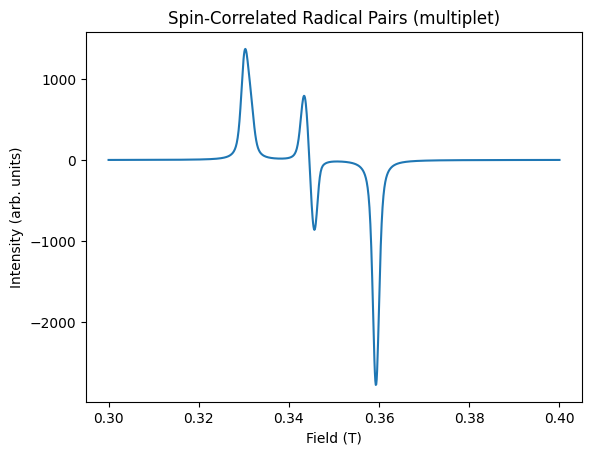

In [9]:
init_populations = [1.0, 0.0, 0.0, 0.0]  # |S>, |T-1>, |T0>, |T1>
context = population.Context(sample=radical_pair,
                             basis="multiplet",
                             init_populations=init_populations, device=device, dtype=dtype)

# And plot the spectra
plot_polirized_spectra(context, radical_pair, "Spin-Correlated Radical Pairs (multiplet)")

The same can be set in the xyz basis

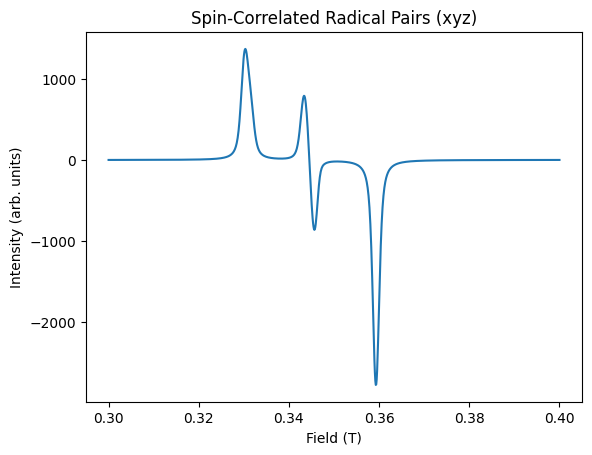

In [10]:
init_populations = [1.0, 0.0, 0.0, 0.0]  # |S>, |Tx>, |Ty>, |Tz>,
context = population.Context(sample=radical_pair,
                             basis="xyz",
                             init_populations=init_populations, device=device, dtype=dtype)

# And plot the spectra
plot_polirized_spectra(context, radical_pair, "Spin-Correlated Radical Pairs (xyz)")

### 1.4. Inter-System Crossing (ISC) Triplets with Hyperfine Coupling

In many photoexcited molecules the triplet state interacts with a nearby nucleus. The Inter-System Crossing (ISC) mechanism unequally populates the triplet sublevels and the hyperfine coupling (HFC) splits these levels.

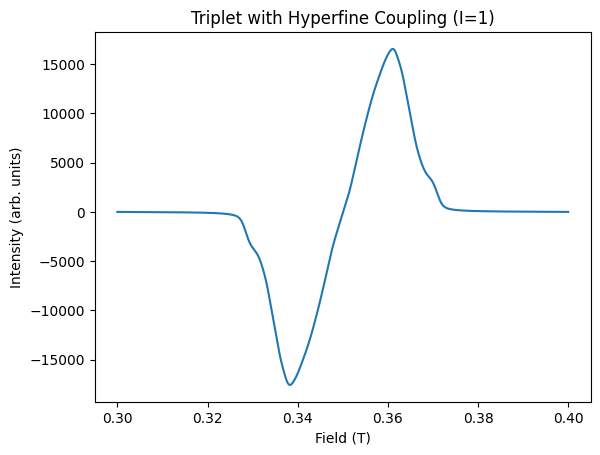

In [11]:
g_tensor = spin_model.Interaction([2.002, 2.002, 2.002], dtype=dtype, device=device)
zfs_interaction = spin_model.DEInteraction([500e6, 100e6], dtype=dtype, device=device) # ZFS parameters D, E in Hz
hfc_interaction = spin_model.Interaction([50e6, 50e6, 100e6], dtype=dtype, device=device) # Axial HFC with I=1

base_spin_system_trip_nuc = spin_model.SpinSystem(
    electrons=[1.0],
    nuclei=["14N"], # I=1 nucleus
    g_tensors=[g_tensor],
    electron_nuclei=[(0, 0, hfc_interaction)], # HFC between e0 and n0
    electron_electron=[(0, 0, zfs_interaction)],
    device=device,
    dtype=dtype
)

triplet_nuc = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system_trip_nuc,
    ham_strain=3e7,
    gauss=0.001,
    lorentz=0.001,
    device=device,
    dtype=dtype,
)

# ISC populates the X, Y, Z states of the triplet. 
# In the "xyz" basis, the states are |Tx, mi>, |Ty, mi>, |Tz, mi>.
# Let's assume unequal population of triplet sublevels: Px=0.3, Py=0.5, Pz=0.2 as in the example 1.1

# However, MaRs doesn't support the direct set of xyz basis. So we use the zfs basis.
# Alternatively it is possible to create the two systems with electrons and nuclei
# and set populations explicitly. 
init_populations_trip_nuc = [
    0.2/3, 0.2/3, 0.2/3,  # Tz
    0.3/3, 0.3/3, 0.3/3,  # Tx
    0.5/3, 0.5/3, 0.5/3   # Ty
]

context_trip_nuc = population.Context(
    sample=triplet_nuc,
    basis="zfs", 
    init_populations=init_populations_trip_nuc, 
    device=device, 
    dtype=dtype
)

plot_polirized_spectra(context_trip_nuc, triplet_nuc, "Triplet with Hyperfine Coupling (I=1)")

The spectrum is close to the spectrum 1.1 since the zfs parameters are quire large and the nucleus sublevels populated equally.

### 1.5. Radical-Triplet Pair (RTP)

Radical-Triplet Pairs (RTPs) are frequently generated in laser flash photolysis experiments (e.g., photoexcited ketones in micelles). In such systems, a doublet radical ($S=1/2$) interacts with a triplet molecule ($S=1$).

The coupled spin system is described by the resulting Doublet ($S_{tot}=1/2$) and Quartet ($S_{tot}=3/2$)** multiplets.

Here we consider two approaches to define the initial spin polarization (populations) of the pair:

1) **Directly in the multiplet system**: Setting the initial populations for the combined Doublet and Quartet states explicitly.
2) **Via tensor multiplication (`@`)**: Considering the doublet radical ($S=1/2$) and the triplet molecule ($S=1$) as two separate, independent subsystems and combining their contexts.

In [12]:
# Set general parameters of spin systems:

g_tensor_rad = spin_model.Interaction([2.003, 2.003, 2.003], dtype=dtype, device=device)
g_tensor_trip = spin_model.Interaction([2.002, 2.002, 2.002], dtype=dtype, device=device)

zfs_interaction = spin_model.DEInteraction([1000e6, 100e6], dtype=dtype, device=device) # Large ZFS for triplet
exchange_interaction = spin_model.Interaction(50e6, dtype=dtype, device=device) # 50 MHz isotropic exchange
dip_interaction = spin_model.DEInteraction([10e6, 0], dtype=dtype, device=device) # Axial dipolar

gauss = 1e-3
lorentz = 1e-3

#### 1.5.1. Manual approach

In this approach, we define the initial spin polarization directly within the combined multiplet basis ($S_{tot} = 1/2$ and $S_{tot} = 3/2$). This is physically meaningful when the generation mechanism (e.g., from a singlet precursor) selectively populates specific total spin states of the pair.

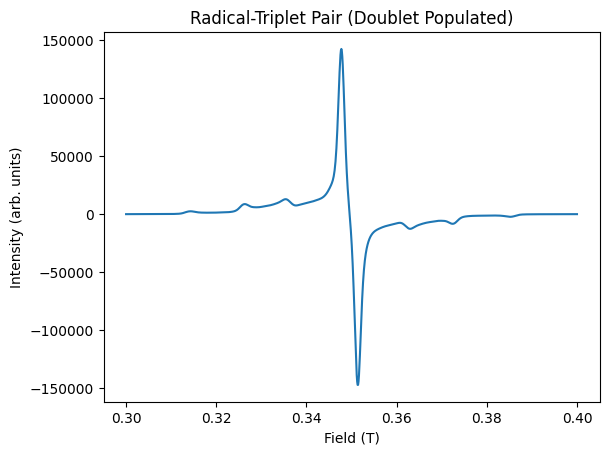

In [13]:
base_spin_system_rt = spin_model.SpinSystem(
    electrons=[0.5, 1.0], # S=1/2 and S=1
    g_tensors=[g_tensor_rad, g_tensor_trip],
    electron_electron=[
        (0, 1, dip_interaction + exchange_interaction), # Inter-spin coupling
        (1, 1, zfs_interaction)                         # Intra-triplet ZFS
    ],
    device=device,
    dtype=dtype
)

radical_triplet = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system_rt,
    gauss=gauss,
    lorentz=lorentz,
    device=device,
    dtype=dtype,
)


# In the multiplet basis |S, Ms>, the states are Doublet (2 states) and Quartet (4 states).
# Let's populate the Doublet states (e.g., from doublet quenching or specific generation).
# Order: |D, -1/2>, |D, +1/2>, |Q, -3/2>, |Q, -1/2>, |Q, +1/2>, |Q, +3/2>
init_populations_rt = [0.5, 0.5, 0.0, 0.0, 0.0, 0.0] 

context_rt = population.Context(
    sample=radical_triplet,
    basis="multiplet",
    init_populations=init_populations_rt, 
    device=device, 
    dtype=dtype
)

plot_polirized_spectra(context_rt, radical_triplet, "Radical-Triplet Pair (Doublet Populated)")

#### 1.5.2. Tensor Multiplication Approach (Independent Subsystems)

Alternatively, we can treat the doublet radical ($S=1/2$) and the triplet molecule ($S=1$) as independent subsystems. We define their initial populations in their respective local bases, and then combine the contexts using the tensor product (`@`). This approach is convenient when the subsystems are generated or relax independently before their mutual interaction is considered.

In [14]:
# Here, additioanlly we need to set two samples: radical, and triplet sample to set the context

base_spin_system_rad = spin_model.SpinSystem(
    electrons=[0.5], # S=1/2
    g_tensors=[g_tensor_rad],
    device=device,
    dtype=dtype
)

radical = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system_rad,
    gauss=gauss,
    lorentz=lorentz,
    device=device,
    dtype=dtype,
)

base_spin_system_triplet = spin_model.SpinSystem(
    electrons=[1.0], # S=1
    g_tensors=[g_tensor_trip],
    electron_electron=[
        (0, 0, zfs_interaction)                         # Intra-triplet ZFS
    ],
    device=device,
    dtype=dtype
)

triplet = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system_triplet,
    gauss=gauss,
    lorentz=lorentz,
    device=device,
    dtype=dtype,
)

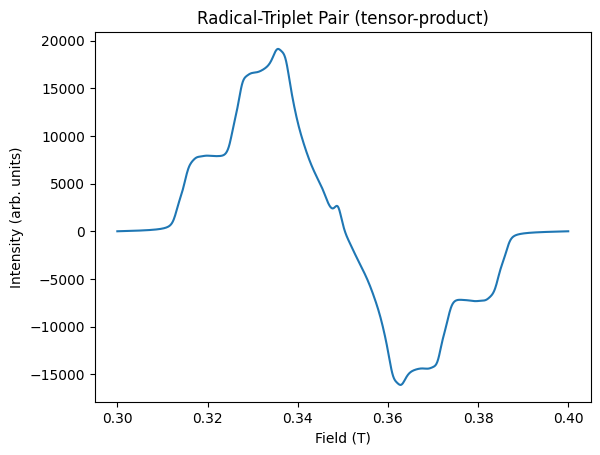

In [15]:
# Set contexts
# Define initial populations for the separate subsystems


init_populations_rad = [0.5, 0.5]  # Set them as approximatly equal. Also it filters off the signal of the radical
context_rad = population.Context(
    sample=radical,
    basis="multiplet",
    init_populations=init_populations_rad, 
    device=device, 
    dtype=dtype
)


init_populations_triplet = [0.2, 0.2, 0.6] # Tx, Ty, Tz
context_triplet = population.Context(
    sample=triplet,
    basis="xyz",
    init_populations=init_populations_triplet, 
    device=device, 
    dtype=dtype
)

# ---- Combine via tensor product ----
context_rt_mult = context_rad @ context_triplet

# Note: we use the same `radical_triplet` MultiOrientedSample as before
plot_polirized_spectra(context_rt_mult, radical_triplet, "Radical-Triplet Pair (tensor-product)")

### 1.6. High-Spin State (S=2) with Large Zero-Field Splitting

Some transition metal complexes (e.g., Fe(II), Cr(II)) or specific defect centers exhibit high-spin ground states. MaRs can handle arbitrary spin values. Here we simulate an S=2 system with large ZFS parameters, where optical excitation selectively populates the outermost spin sublevels (Ms = +-2).

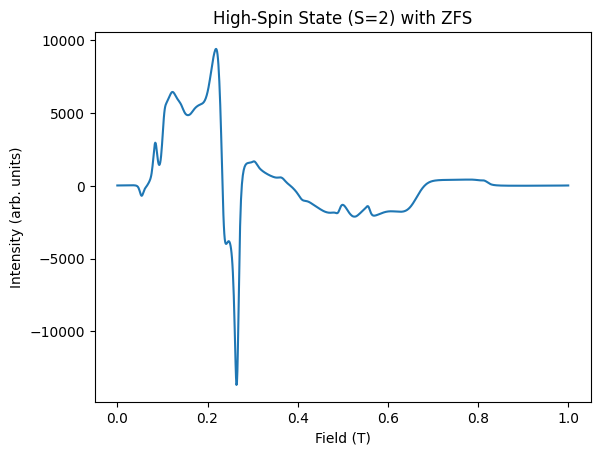

In [16]:
g_tensor_hs = spin_model.Interaction([2.04, 2.07, 2.15], dtype=dtype, device=device) # anisotropic
zfs_hs = spin_model.DEInteraction([5000e6, 500e6], dtype=dtype, device=device) # Large ZFS for S=2 (D and E parameters in Hz)

base_spin_system_hs = spin_model.SpinSystem(
    electrons=[2.0], # S=2
    g_tensors=[g_tensor_hs],
    electron_electron=[(0, 0, zfs_hs)],
    device=device,
    dtype=dtype
)


high_spin_sample = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system_hs,
    ham_strain=1e8,
    gauss=0.005,
    lorentz=0.005,
    device=device,
    dtype=dtype,
)

# Assume optical excitation populates the highest energy sublevels (|±2>)
# In "multiplet" basis, the 5 states are ordered by Ms: |-2>, |-1>, |0>, |1>, |2>
init_populations_hs = [0.5, 0.0, 0.0, 0.0, 0.5] 

context_hs = population.Context(
    sample=high_spin_sample,
    basis="multiplet",
    init_populations=init_populations_hs, 
    device=device, 
    dtype=dtype
)

plot_polirized_spectra(context_hs, high_spin_sample, "High-Spin State (S=2) with ZFS", field_range=[0.0, 1.0])

# 2. Time-resolved EPR (2D)

We now compute time-resolved spectra for three systems from Section 1 using the population (kinetic) approach: level populations evolve as $d\mathbf{n}/dt = K\mathbf{n}(t)$, with `decay_rates` (irreversible loss) and `thermal_rates` (population transfer) set in `population.Context`, and spectra are produced with `spectra_manager.CoupledTimeSpectra`. 

### 2.1. ISC Triplet: Spin-Lattice Relaxation and Phosphorescence Decay

The ISC-polarized triplet (Section 1.1) relaxes between Zeeman sublevels (spin-lattice relaxation, ~1 µs) while decaying to the ground state (phosphorescence, ~100 µs lifetime).

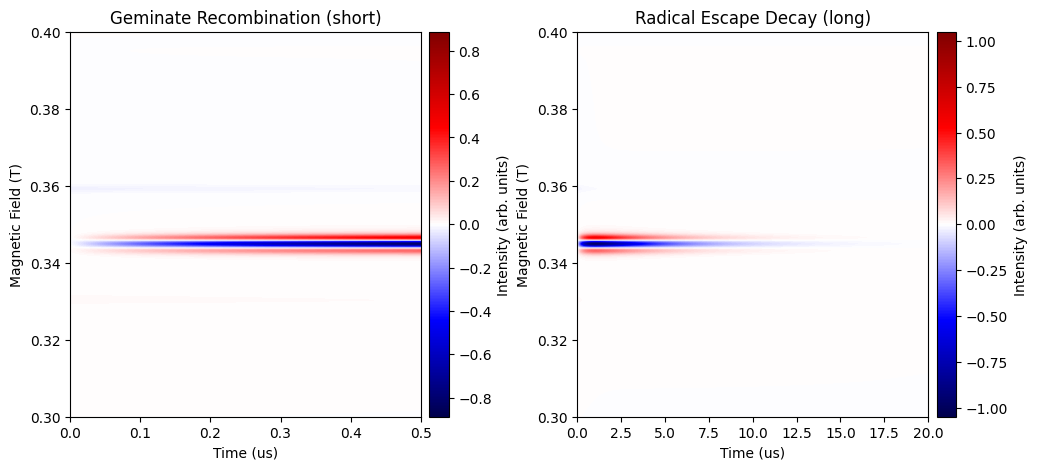

In [17]:
# Reuse the SCRP sample (Section 1.3)
g_tensor_1 = spin_model.Interaction([2.02, 2.03, 2.04], dtype=dtype, device=device)
g_tensor_2 = spin_model.Interaction([2.03, 2.025, 2.025], dtype=dtype, device=device)
dip_interaction = spin_model.DEInteraction([100e6, 10e6], dtype=dtype, device=device)
exchange_interaction = spin_model.Interaction(400e6, dtype=dtype, device=device)

base_spin_system = spin_model.SpinSystem(
    electrons=[0.5, 0.5],
    g_tensors=[g_tensor_1, g_tensor_2],
    electron_electron=[(0, 1, dip_interaction + exchange_interaction)],
    device=device, dtype=dtype
)

radical_pair = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system,
    gauss=0.001, lorentz=0.001,
    device=device, dtype=dtype
)

# Born in the pure singlet state: |S>, |T-1>, |T0>, |T1>
init_populations = [1.0, 0.0, 0.0, 0.0]

# Hyperfine-driven S-T0 mixing
thermal_rates = torch.zeros((4, 4), device=device, dtype=dtype)
thermal_rates[0, 2] = 1e6
thermal_rates[2, 0] = 1e6

# Fast geminate recombination from S, slower decay of triplet-born pairs
decay_rates = torch.tensor([5e5, 1e5, 1e5, 1e5], device=device, dtype=dtype)

context_rp = population.Context(
    sample=radical_pair, basis="multiplet",
    init_populations=init_populations,
    decay_rates=decay_rates,
    thermal_rates=thermal_rates,
    device=device, dtype=dtype
)

tr_creator = spectra_manager.CoupledTimeSpectra(
    freq=9.8e9, sample=radical_pair, harmonic=0,
    context=context_rp, temperature=300.0,
    device=device, dtype=dtype
)

fields = torch.linspace(0.30, 0.40, 1000, dtype=dtype, device=device)
time_short = torch.linspace(0.0, 5e-7, 400, dtype=dtype, device=device)  # S-T0 mixing / geminate recombination
time_long  = torch.linspace(0.0, 2e-5, 400, dtype=dtype, device=device)  # radical decay

spec_short = tr_creator(radical_pair, fields, time_short).cpu().numpy()
spec_long  = tr_creator(radical_pair, fields, time_long).cpu().numpy()
norm = np.max(np.abs(spec_long))
spec_short = spec_short / norm
spec_long  = spec_long / norm

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))
plt.sca(ax0)
visualization.plot_2d_timeresolved(fields, time_short, spec_short, time_unit="us")
plt.title("Geminate Recombination (short)")
plt.sca(ax1)
visualization.plot_2d_timeresolved(fields, time_long, spec_long, time_unit="us")
plt.title("Radical Escape Decay (long)")
plt.show()

### 2.2. Spin-Correlated Radical Pair: Recombination Kinetics

The singlet-born SCRP (Section 1.3) undergoes hyperfine-driven S–T0 population mixing (~50 ns) together with fast geminate recombination from S and slower diffusive escape/decay of the triplet-born pairs.

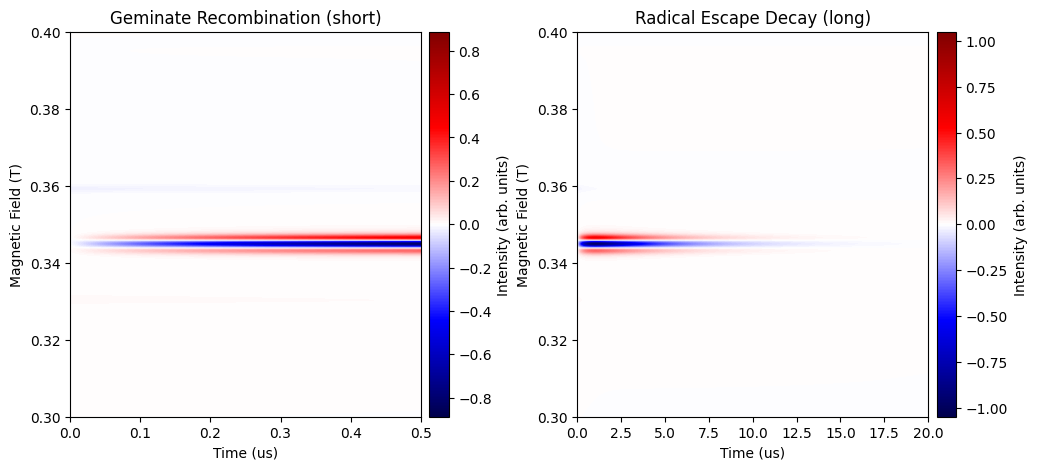

In [18]:
# Reuse the SCRP sample (Section 1.3)
g_tensor_1 = spin_model.Interaction([2.02, 2.03, 2.04], dtype=dtype, device=device)
g_tensor_2 = spin_model.Interaction([2.03, 2.025, 2.025], dtype=dtype, device=device)
dip_interaction = spin_model.DEInteraction([100e6, 10e6], dtype=dtype, device=device)
exchange_interaction = spin_model.Interaction(400e6, dtype=dtype, device=device)

base_spin_system = spin_model.SpinSystem(
    electrons=[0.5, 0.5],
    g_tensors=[g_tensor_1, g_tensor_2],
    electron_electron=[(0, 1, dip_interaction + exchange_interaction)],
    device=device, dtype=dtype
)

radical_pair = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system,
    gauss=0.001, lorentz=0.001,
    device=device, dtype=dtype
)

# Born in the pure singlet state: |S>, |T-1>, |T0>, |T1>
init_populations = [1.0, 0.0, 0.0, 0.0]

# Hyperfine-driven S-T0 mixing
thermal_rates = torch.zeros((4, 4), device=device, dtype=dtype)
thermal_rates[0, 2] = 1e6
thermal_rates[2, 0] = 1e6

# Fast geminate recombination from S, slower decay of triplet-born pairs
decay_rates = torch.tensor([5e5, 1e5, 1e5, 1e5], device=device, dtype=dtype)

context_rp = population.Context(
    sample=radical_pair, basis="multiplet",
    init_populations=init_populations,
    decay_rates=decay_rates,
    thermal_rates=thermal_rates,
    device=device, dtype=dtype
)

tr_creator = spectra_manager.CoupledTimeSpectra(
    freq=9.8e9, sample=radical_pair, harmonic=0,
    context=context_rp, temperature=300.0,
    device=device, dtype=dtype
)

fields = torch.linspace(0.30, 0.40, 1000, dtype=dtype, device=device)
time_short = torch.linspace(0.0, 5e-7, 400, dtype=dtype, device=device)  # S-T0 mixing / geminate recombination
time_long  = torch.linspace(0.0, 2e-5, 400, dtype=dtype, device=device)  # radical decay

spec_short = tr_creator(radical_pair, fields, time_short).cpu().numpy()
spec_long  = tr_creator(radical_pair, fields, time_long).cpu().numpy()
norm = np.max(np.abs(spec_long))
spec_short = spec_short / norm
spec_long  = spec_long / norm

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))
plt.sca(ax0)
visualization.plot_2d_timeresolved(fields, time_short, spec_short, time_unit="us")
plt.title("Geminate Recombination (short)")
plt.sca(ax1)
visualization.plot_2d_timeresolved(fields, time_long, spec_long, time_unit="us")
plt.title("Radical Escape Decay (long)")
plt.show()

### 2.3. High-Spin Defect: Spin-Lattice Relaxation to Equilibrium

The optically polarized S=2 center (Section 1.6) relaxes toward Boltzmann equilibrium through a sequential ΔMs = ±1 spin-lattice relaxation cascade.

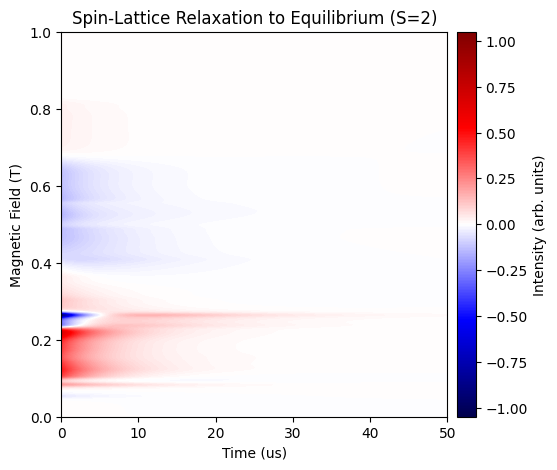

In [19]:
# Reuse the S=2 high-spin sample (Section 1.6)
g_tensor_hs = spin_model.Interaction([2.04, 2.07, 2.15], dtype=dtype, device=device)
zfs_hs = spin_model.DEInteraction([5000e6, 500e6], dtype=dtype, device=device)

base_spin_system_hs = spin_model.SpinSystem(
    electrons=[2.0],
    g_tensors=[g_tensor_hs],
    electron_electron=[(0, 0, zfs_hs)],
    device=device, dtype=dtype
)

high_spin_sample = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system_hs,
    ham_strain=1e8, gauss=0.005, lorentz=0.005,
    device=device, dtype=dtype
)

# Optical excitation populates the outermost sublevels (Ms = +-2): |-2>, |-1>, |0>, |1>, |2>
init_populations_hs = [0.5, 0.0, 0.0, 0.0, 0.5]

# Sequential nearest-neighbor spin-lattice relaxation cascade toward Boltzmann equilibrium
thermal_rates = torch.zeros((5, 5), device=device, dtype=dtype)
for i in range(4):
    thermal_rates[i, i + 1] = 1e5
    thermal_rates[i + 1, i] = 1e5

context_hs = population.Context(
    sample=high_spin_sample, basis="multiplet",
    init_populations=init_populations_hs,
    thermal_rates=thermal_rates,
    device=device, dtype=dtype
)

tr_creator = spectra_manager.CoupledTimeSpectra(
    freq=9.8e9, sample=high_spin_sample, harmonic=0,
    context=context_hs, temperature=300.0,
    device=device, dtype=dtype
)

fields = torch.linspace(0.0, 1.0, 1000, dtype=dtype, device=device)
time_axis = torch.linspace(0.0, 5e-5, 400, dtype=dtype, device=device)  # relaxation to equilibrium

spec = tr_creator(high_spin_sample, fields, time_axis).cpu().numpy()
spec = spec / np.max(np.abs(spec))

plt.figure(figsize=(6, 5))
visualization.plot_2d_timeresolved(fields, time_axis, spec, time_unit="us")
plt.title("Spin-Lattice Relaxation to Equilibrium (S=2)")
plt.show()